# 06 — Physics-Informed Unsupervised Autoencoder

**Goal.** Replicate the core idea of Marx & Gryllias 2022 (KU Leuven, corpus paper #2) on NASA IMS Set 2: train an autoencoder on **healthy data only**, augment it with **synthetic faulty data derived from domain knowledge** (bearing fault frequencies), and use the resulting latent space as a per-fault-mode health indicator.

**Why this matters for the proposal-phase narrative.** All preceding notebooks (02-05) train *supervised* models with hand-curated labels — feasible on the published NASA IMS dataset, but a real industrial deployment in a mining plant rarely has end-of-life labelled data on hand. The strongest cluster in the 2024-2026 literature surveyed in `reference/_SYNTHESIS.md` is the unsupervised / weakly-supervised health-indicator work. This notebook is the proof-of-concept that the pipeline established in 02-05 can be re-implemented under that label-free regime.

**Method (from Marx & Gryllias 2022).**

1. **Input feature**: per-snapshot Squared Envelope Spectrum (SES). Compute via Hilbert envelope → FFT magnitude squared.
2. **Healthy training corpus**: only the rows labelled Normal in notebook 02. The model never sees any failure data.
3. **Synthetic faulty augmentation**: for each known fault mode (outer race, inner race, ball element), create augmented spectra by adding a triangular peak at the corresponding fault frequency in the SES plus its first few harmonics. The fault frequency expectations come from the geometry-derived BPFO / BPFI / BSF values.
4. **Autoencoder loss**:
   - Reconstruction loss on healthy data (standard MSE).
   - Latent direction loss: enforce that the latent embedding of an augmented (mode *i*) sample deviates from the healthy embedding in a mode-specific direction, with maximally different directions across modes.
   - Latent magnitude loss: enforce that augmented samples sit at a consistent (large) distance from the healthy cluster regardless of mode.
5. **Inference**: project a new snapshot onto each fault direction; the projection magnitude is the per-mode health indicator. A spike on the outer-race direction = the bearing is failing in that mode.

In [1]:
from __future__ import annotations

import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from scipy.signal import hilbert

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

DEVICE = torch.device("mps") if torch.backends.mps.is_available() else (
    torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
)
print(f"PyTorch {torch.__version__} | device: {DEVICE}")
torch.manual_seed(42)
np.random.seed(42)

NB_DIR = Path(__file__).resolve().parent if "__file__" in globals() else Path.cwd()
PROJECT_ROOT = NB_DIR.parent
FIG_DIR = PROJECT_ROOT / "figures"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FIG_DIR.mkdir(exist_ok=True)

# Bearing fault frequencies at 2000 RPM (from notebook 02)
FAULT_FREQS = {"BPFO": 236.4, "BPFI": 296.9, "BSF": 139.9}
SAMPLE_RATE_HZ = 20_000

PyTorch 2.10.0.dev20251110 | device: mps


## 1. Load Set 2 raw snapshots and compute Squared Envelope Spectrum

Load the cached raw windows from the LOBO setup, filter to Set 2 only, and aggregate windows back to per-snapshot signals (25 windows × 800 = 20,000 samples per snapshot — slightly less than the 20,480 in the original file, but enough for SES computation at the sample rate).

For each snapshot we compute SES = |FFT(|hilbert(x)|²)|. Truncate to 1024 frequency bins for a manageable AE input dimension.

In [2]:
# Load raw windows + their metadata + the per-snapshot features (we'll need state labels)
raw_windows = np.load(PROCESSED_DIR / "raw_windows.npy", mmap_mode="r")
raw_meta = pd.read_parquet(PROCESSED_DIR / "raw_windows_meta.parquet")

# Filter to Set 2 only
set2_mask = (raw_meta["set"] == 2).to_numpy()
print(f"Set 2 rows: {set2_mask.sum():,}")

# Load the labelled features to recover the per-snapshot state
features_df = pd.read_parquet(PROCESSED_DIR / "all_sets_features.parquet")
features_set2 = features_df[features_df["set"] == 2].reset_index(drop=True)

# Reconstruct the per-snapshot signal by concatenating the 25 windows that came from the same file × bearing
N_WINDOWS_PER_FILE = 25
WINDOW_SAMPLES = 800

Set 2 rows: 98,400


In [3]:
def per_snapshot_ses(raw_mat: np.ndarray, meta: pd.DataFrame, max_bins: int = 1024) -> tuple[np.ndarray, pd.DataFrame]:
    """Aggregate windows per (file × bearing) and compute SES.

    Returns:
      X     — (n_snapshots, max_bins) float32
      keys  — DataFrame with timestamp, file, bearing, bearing_uid for each row
    """
    groups = meta.groupby(["file", "bearing"], sort=False)
    n_snap = groups.ngroups
    X = np.empty((n_snap, max_bins), dtype=np.float32)
    keys = []
    for i, ((fname, bearing), grp) in enumerate(groups):
        idxs = grp.index.to_numpy()
        # concatenate the 25 windows back into a 20,000-sample signal
        signal = raw_mat[idxs].reshape(-1)
        # Squared envelope spectrum
        env = np.abs(hilbert(signal))
        # remove DC
        env = env - env.mean()
        spec = np.abs(np.fft.rfft(env)) ** 2
        spec = spec[:max_bins]
        # log-normalise to reduce dynamic range
        spec = np.log1p(spec)
        # min-max normalise per snapshot
        spec_min, spec_max = spec.min(), spec.max()
        spec = (spec - spec_min) / (spec_max - spec_min + 1e-9)
        X[i] = spec.astype(np.float32)
        keys.append({"file": fname, "bearing": bearing, "timestamp": grp["timestamp"].iloc[0],
                     "bearing_uid": int(grp["bearing_uid"].iloc[0])})
    return X, pd.DataFrame(keys)


# Compute SES for Set 2 only (smaller subset for first pass)
set2_indices = np.where(set2_mask)[0]
print(f"Computing SES for {set2_indices.size:,} Set 2 rows = "
      f"{set2_indices.size // (N_WINDOWS_PER_FILE):,} snapshots")
t0 = time.time()
X_ses, keys = per_snapshot_ses(np.array(raw_windows[set2_indices]), raw_meta.iloc[set2_indices].reset_index(drop=True))
print(f"SES matrix: {X_ses.shape} in {time.time() - t0:.1f}s")

# Attach per-snapshot state label from the features dataframe
ses_df = keys.merge(
    features_set2[["file", "bearing", "state"]].drop_duplicates(["file", "bearing"]),
    on=["file", "bearing"], how="left"
)
print(f"Joined: {ses_df.shape}")
print(ses_df["state"].value_counts().rename({0: "Normal", 1: "Degraded", 2: "Critical"}))

Computing SES for 98,400 Set 2 rows = 3,936 snapshots


SES matrix: (3936, 1024) in 3.3s
Joined: (3936, 5)
state
Normal      3486
Critical     441
Degraded       9
Name: count, dtype: int64


## 2. Build training set: healthy snapshots only

Take all Set 2 snapshots whose state is Normal. Hold out a 20% validation split.

In [4]:
healthy_mask = ses_df["state"] == 0
X_healthy = X_ses[healthy_mask.to_numpy()]
print(f"Healthy snapshots: {X_healthy.shape}")

# Random 80/20 train/val
rng = np.random.default_rng(seed=42)
perm = rng.permutation(len(X_healthy))
n_val = int(0.2 * len(X_healthy))
val_idx = perm[:n_val]
train_idx = perm[n_val:]
X_train_h = X_healthy[train_idx]
X_val_h = X_healthy[val_idx]
print(f"Train: {X_train_h.shape}, Val: {X_val_h.shape}")

Healthy snapshots: (3486, 1024)
Train: (2789, 1024), Val: (697, 1024)


## 3. Synthetic faulty data via domain-knowledge augmentation

For each fault mode (outer race / inner race / ball element), generate augmented spectra by adding a triangular peak at the corresponding fault frequency plus its first three harmonics. The peak height is sampled from a small distribution to add variety.

At our SES sampling, frequency bin index ≈ fault_freq × N / sample_rate × 2 (since SES uses the envelope's FFT).

In [5]:
FREQ_RESOLUTION = SAMPLE_RATE_HZ / 2 / 1024   # Hz per SES bin
print(f"SES resolution: {FREQ_RESOLUTION:.2f} Hz per bin")


def add_triangular_peak(spec: np.ndarray, center_hz: float, width_bins: int, height: float) -> np.ndarray:
    """Add a triangular peak centred at center_hz with given height."""
    center = int(center_hz / FREQ_RESOLUTION)
    out = spec.copy()
    for i in range(-width_bins, width_bins + 1):
        bin_idx = center + i
        if 0 <= bin_idx < len(out):
            mag = height * (1 - abs(i) / max(width_bins, 1))
            out[bin_idx] = min(1.0, out[bin_idx] + mag)
    return out


def augment_for_mode(spec: np.ndarray, mode: str, rng: np.random.Generator) -> np.ndarray:
    """Augment a healthy spectrum toward a specific fault mode."""
    out = spec.copy()
    f0 = FAULT_FREQS[{"outer": "BPFO", "inner": "BPFI", "ball": "BSF"}[mode]]
    # Add peaks at f0, 2*f0, 3*f0
    for harmonic in (1, 2, 3):
        height = rng.uniform(0.05, 0.15) / harmonic   # decay with harmonic
        out = add_triangular_peak(out, f0 * harmonic, width_bins=2, height=height)
    return out


# Generate augmented data: for each healthy training spectrum, create 3 augmented variants (one per mode)
def build_augmented(X_healthy: np.ndarray, rng: np.random.Generator) -> tuple[np.ndarray, np.ndarray]:
    n = len(X_healthy)
    X_aug = np.empty((3 * n, X_healthy.shape[1]), dtype=np.float32)
    y_mode = np.empty(3 * n, dtype=np.int64)
    for i, x in enumerate(X_healthy):
        for j, mode in enumerate(["outer", "inner", "ball"]):
            X_aug[3 * i + j] = augment_for_mode(x, mode, rng)
            y_mode[3 * i + j] = j
    return X_aug, y_mode


X_aug, y_aug_mode = build_augmented(X_train_h, np.random.default_rng(seed=42))
print(f"Augmented training: {X_aug.shape}, mode counts: {dict(zip(*np.unique(y_aug_mode, return_counts=True)))}")

SES resolution: 9.77 Hz per bin
Augmented training: (8367, 1024), mode counts: {np.int64(0): np.int64(2789), np.int64(1): np.int64(2789), np.int64(2): np.int64(2789)}


## 4. Visualise: healthy vs augmented spectra

A quick sanity check that the triangular peaks landed where we expect.

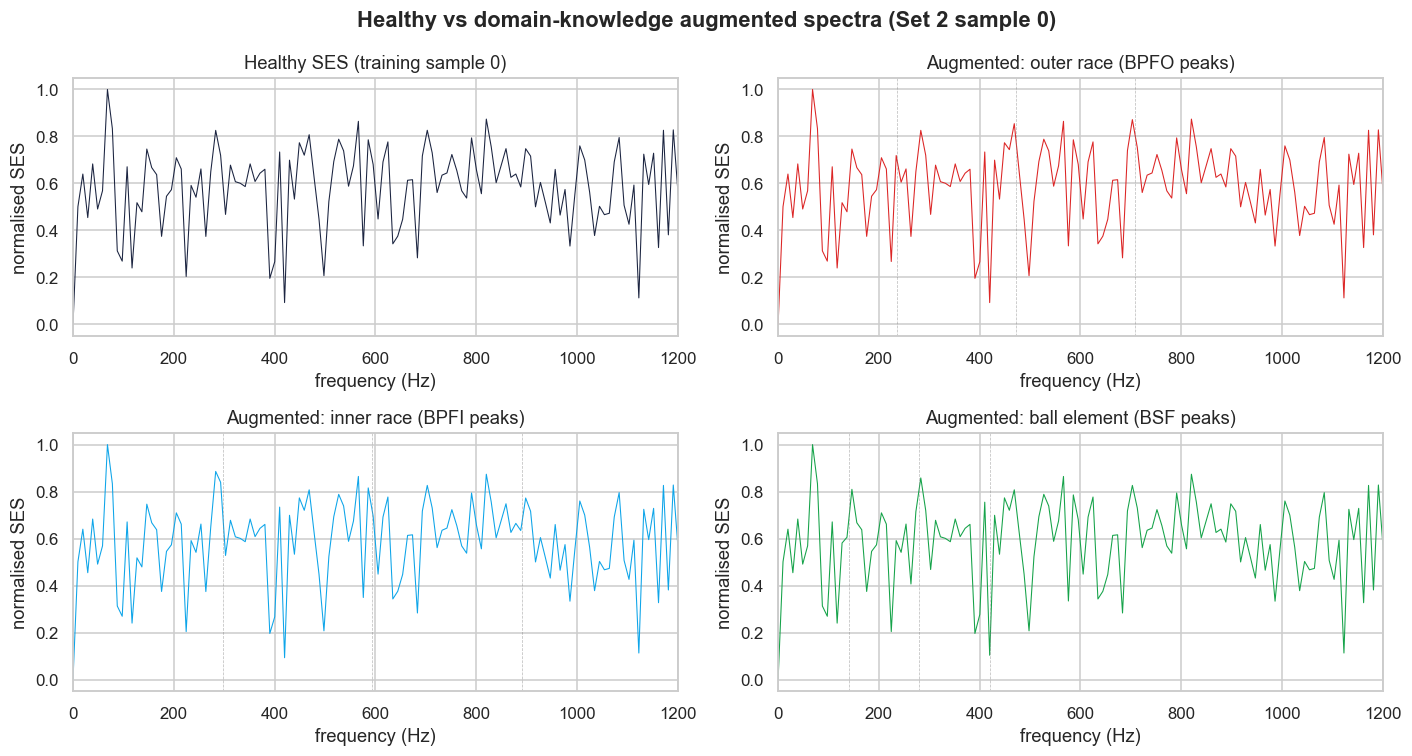

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(13, 7))
freq_axis = np.arange(X_healthy.shape[1]) * FREQ_RESOLUTION

axes[0, 0].plot(freq_axis, X_train_h[0], lw=0.7, color="#1c2541")
axes[0, 0].set_title("Healthy SES (training sample 0)")
axes[0, 0].set_xlim(0, 1200)

mode_titles = {0: "outer race (BPFO peaks)", 1: "inner race (BPFI peaks)", 2: "ball element (BSF peaks)"}
mode_colors = {0: "#dc2626", 1: "#0ea5e9", 2: "#16a34a"}
for j in range(3):
    ax = axes.flat[j + 1]
    ax.plot(freq_axis, X_aug[3 * 0 + j], lw=0.7, color=mode_colors[j])
    ax.set_title(f"Augmented: {mode_titles[j]}")
    ax.set_xlim(0, 1200)
    # mark expected fault frequency
    f0 = {"outer": FAULT_FREQS["BPFO"], "inner": FAULT_FREQS["BPFI"], "ball": FAULT_FREQS["BSF"]}[
        ["outer", "inner", "ball"][j]
    ]
    for harm in (1, 2, 3):
        ax.axvline(f0 * harm, color="grey", ls="--", lw=0.5, alpha=0.5)

for ax in axes.flat:
    ax.set_xlabel("frequency (Hz)")
    ax.set_ylabel("normalised SES")
fig.suptitle("Healthy vs domain-knowledge augmented spectra (Set 2 sample 0)", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "11_ae_augmentation.png", dpi=130, bbox_inches="tight")
plt.show()

## 5. Autoencoder model

A small dense AE: 1024 → 256 → 64 → 8 (bottleneck) → 64 → 256 → 1024. Use the bottleneck embeddings as the per-fault-mode health indicator inputs.

In [7]:
INPUT_DIM = X_healthy.shape[1]
LATENT_DIM = 8


class DomainAE(nn.Module):
    def __init__(self, input_dim: int = INPUT_DIM, latent_dim: int = LATENT_DIM):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 256), nn.ReLU(),
            nn.Linear(256, 64), nn.ReLU(),
            nn.Linear(64, latent_dim),
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64), nn.ReLU(),
            nn.Linear(64, 256), nn.ReLU(),
            nn.Linear(256, input_dim), nn.Sigmoid(),
        )

    def encode(self, x):
        return self.encoder(x)

    def forward(self, x):
        z = self.encode(x)
        recon = self.decoder(z)
        return recon, z


ae = DomainAE().to(DEVICE)
n_params = sum(p.numel() for p in ae.parameters())
print(f"Domain-AE: {n_params:,} parameters")

Domain-AE: 559,752 parameters


## 6. Custom loss

For a batch of healthy spectra h and three matched augmented spectra (one per mode), the loss has three terms:

- **Reconstruction**: MSE on healthy → healthy.
- **Latent direction**: dot-product orthogonality penalty between the per-mode latent shifts `z(aug_i) − z(h)`.
- **Latent magnitude**: enforce that `‖z(aug_i) − z(h)‖ = 1` for all modes.

In [8]:
def domain_loss(model, h: torch.Tensor, augs: list[torch.Tensor], lambda_dir: float = 0.1, lambda_mag: float = 0.1):
    recon_h, z_h = model(h)
    rec_loss = F.mse_loss(recon_h, h)

    deltas = []
    for a in augs:
        _, z_a = model(a)
        deltas.append(z_a - z_h)
    deltas = torch.stack(deltas, dim=0)   # (3 modes, batch, latent_dim)

    # Latent direction: pairwise orthogonality
    norms = deltas.norm(dim=2, keepdim=True) + 1e-8
    u = deltas / norms
    # dot products between (mode 0, mode 1), (mode 0, mode 2), (mode 1, mode 2)
    dir_loss = (u[0] * u[1]).sum(dim=1).pow(2).mean() +                (u[0] * u[2]).sum(dim=1).pow(2).mean() +                (u[1] * u[2]).sum(dim=1).pow(2).mean()

    # Latent magnitude: each delta has unit norm
    mag_loss = (norms.squeeze(-1) - 1.0).pow(2).mean()

    total = rec_loss + lambda_dir * dir_loss + lambda_mag * mag_loss
    return total, rec_loss.item(), dir_loss.item(), mag_loss.item()

## 7. Train

In [9]:
EPOCHS = 30
BATCH = 256

X_train_t = torch.from_numpy(X_train_h)
# Build matched augmented tensors per mode
X_aug_outer = torch.from_numpy(X_aug[y_aug_mode == 0])
X_aug_inner = torch.from_numpy(X_aug[y_aug_mode == 1])
X_aug_ball  = torch.from_numpy(X_aug[y_aug_mode == 2])

ds = TensorDataset(X_train_t, X_aug_outer, X_aug_inner, X_aug_ball)
loader = DataLoader(ds, batch_size=BATCH, shuffle=True, num_workers=0)

optimiser = torch.optim.Adam(ae.parameters(), lr=1e-3, weight_decay=1e-5)

history = []
t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    ae.train()
    losses = []
    for h, ao, ai, ab in loader:
        h = h.to(DEVICE)
        ao, ai, ab = ao.to(DEVICE), ai.to(DEVICE), ab.to(DEVICE)
        loss, rec, dir_l, mag_l = domain_loss(ae, h, [ao, ai, ab])
        optimiser.zero_grad()
        loss.backward()
        optimiser.step()
        losses.append((loss.item(), rec, dir_l, mag_l))
    arr = np.array(losses)
    history.append((epoch, *arr.mean(axis=0)))
    if epoch % 5 == 0 or epoch == 1:
        print(f"  epoch {epoch:2d}/{EPOCHS} | loss {arr[:, 0].mean():.4f} | "
              f"rec {arr[:, 1].mean():.4f}  dir {arr[:, 2].mean():.4f}  mag {arr[:, 3].mean():.4f}")
print(f"\ntraining done in {time.time() - t0:.1f}s")

hist_df = pd.DataFrame(history, columns=["epoch", "total", "rec", "dir", "mag"])

  epoch  1/30 | loss 0.1449 | rec 0.0266  dir 0.1873  mag 0.9955


  epoch  5/30 | loss 0.1228 | rec 0.0237  dir 0.0004  mag 0.9909


  epoch 10/30 | loss 0.1201 | rec 0.0216  dir 0.0001  mag 0.9843


  epoch 15/30 | loss 0.1169 | rec 0.0213  dir 0.0002  mag 0.9557


  epoch 20/30 | loss 0.1067 | rec 0.0212  dir 0.0002  mag 0.8551


  epoch 25/30 | loss 0.0807 | rec 0.0211  dir 0.0005  mag 0.5951


  epoch 30/30 | loss 0.0598 | rec 0.0211  dir 0.0006  mag 0.3865

training done in 6.7s


## 8. Health indicator inference

For each Set 2 snapshot, compute the latent embedding. The per-mode "deviation magnitude" along the expected fault direction (from the augmented training) is the health indicator. We expect bearing 1's outer-race direction to fire monotonically during its failure progression.

In [10]:
def encode(model, X: np.ndarray, batch: int = 512) -> np.ndarray:
    model.eval()
    out = []
    with torch.no_grad():
        for s in range(0, len(X), batch):
            x = torch.from_numpy(X[s:s + batch]).to(DEVICE)
            z = model.encode(x).cpu().numpy()
            out.append(z)
    return np.concatenate(out)


# Encode all Set 2 SES snapshots and the augmented training data
z_all = encode(ae, X_ses)                    # (n_snapshots, 8)
z_h_train = encode(ae, X_train_h)
z_aug_outer = encode(ae, X_aug[y_aug_mode == 0])
z_aug_inner = encode(ae, X_aug[y_aug_mode == 1])
z_aug_ball  = encode(ae, X_aug[y_aug_mode == 2])

# Expected fault directions as mean shifts in latent space
mu_h = z_h_train.mean(axis=0)
direction_outer = (z_aug_outer.mean(axis=0) - mu_h)
direction_inner = (z_aug_inner.mean(axis=0) - mu_h)
direction_ball  = (z_aug_ball.mean(axis=0)  - mu_h)

# Normalise
direction_outer = direction_outer / (np.linalg.norm(direction_outer) + 1e-8)
direction_inner = direction_inner / (np.linalg.norm(direction_inner) + 1e-8)
direction_ball  = direction_ball  / (np.linalg.norm(direction_ball)  + 1e-8)

# Per-snapshot projection along each direction (the health indicator)
deltas_all = z_all - mu_h
hi_outer = deltas_all @ direction_outer
hi_inner = deltas_all @ direction_inner
hi_ball  = deltas_all @ direction_ball

ses_df["hi_outer"] = hi_outer
ses_df["hi_inner"] = hi_inner
ses_df["hi_ball"]  = hi_ball
ses_df.head()

,file,bearing,timestamp,bearing_uid,state,hi_outer,hi_inner,hi_ball
0,2004.02.12.10.32.39,1,2004-02-12 10:32:39,21,0,0.076553,-0.777300,1.274040
1,2004.02.12.10.32.39,2,2004-02-12 10:32:39,22,0,-0.031484,-0.717725,2.510243
2,2004.02.12.10.32.39,3,2004-02-12 10:32:39,23,0,-0.040017,-0.409643,-1.207540
3,2004.02.12.10.32.39,4,2004-02-12 10:32:39,24,0,0.038917,0.045025,0.114830
4,2004.02.12.10.42.39,1,2004-02-12 10:42:39,21,0,0.014835,1.124932,-3.459682


## 9. Visualise the per-mode health indicator on each bearing

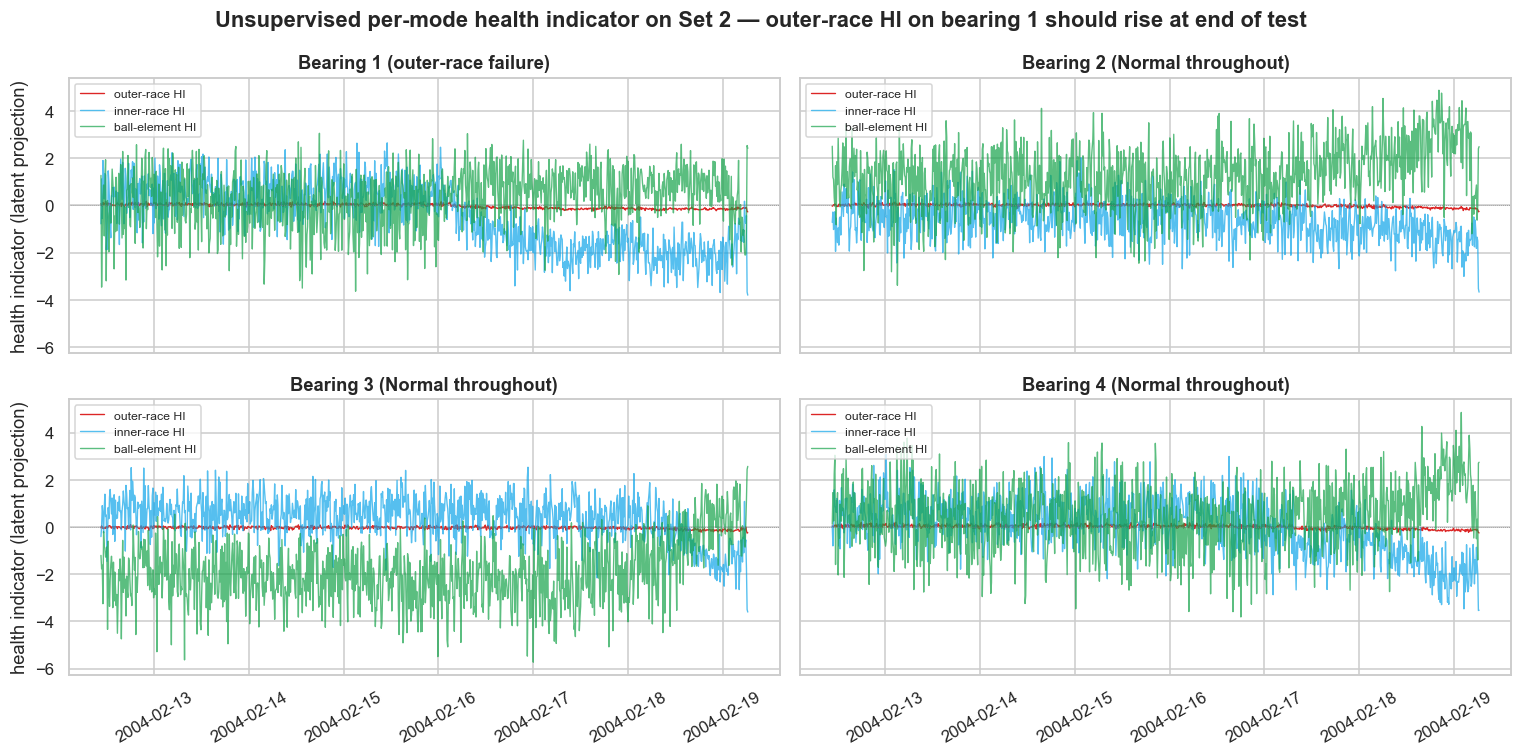

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True, sharey=True)
for ax, bearing in zip(axes.flat, [1, 2, 3, 4]):
    sub = ses_df[ses_df["bearing"] == bearing].sort_values("timestamp")
    ax.plot(sub["timestamp"], sub["hi_outer"], lw=0.9, color="#dc2626", label="outer-race HI")
    ax.plot(sub["timestamp"], sub["hi_inner"], lw=0.9, color="#0ea5e9", label="inner-race HI", alpha=0.7)
    ax.plot(sub["timestamp"], sub["hi_ball"],  lw=0.9, color="#16a34a", label="ball-element HI", alpha=0.7)
    ax.axhline(0, color="grey", ls=":", lw=0.5)
    title = f"Bearing {bearing}"
    if bearing == 1:
        title += " (outer-race failure)"
    else:
        title += " (Normal throughout)"
    ax.set_title(title, fontweight="bold")
    ax.legend(loc="upper left", fontsize=8)
    ax.tick_params(axis="x", labelrotation=30)

axes[0, 0].set_ylabel("health indicator (latent projection)")
axes[1, 0].set_ylabel("health indicator (latent projection)")
fig.suptitle("Unsupervised per-mode health indicator on Set 2 — outer-race HI on bearing 1 should rise at end of test", fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "12_ae_health_indicators.png", dpi=130, bbox_inches="tight")
plt.show()

## 10. Quantitative test

If the unsupervised HI works, on bearing 1 (which has an outer-race failure) the `hi_outer` time series should rank high relative to `hi_inner` and `hi_ball` — *and* high relative to the same indicator on bearings 2-4 (which are healthy throughout).

In [12]:
# Mean and max HI per bearing on the Critical-labelled snapshots of bearing 1, vs Normal snapshots elsewhere
critical_b1 = ses_df[(ses_df["bearing"] == 1) & (ses_df["state"] == 2)]
normal_others = ses_df[(ses_df["bearing"] != 1) & (ses_df["state"] == 0)]
normal_b1 = ses_df[(ses_df["bearing"] == 1) & (ses_df["state"] == 0)]

summary = pd.DataFrame({
    "subset": ["B1 critical (outer-race failure)", "B1 normal", "B2-B4 normal"],
    "n": [len(critical_b1), len(normal_b1), len(normal_others)],
    "hi_outer_mean": [critical_b1["hi_outer"].mean(), normal_b1["hi_outer"].mean(), normal_others["hi_outer"].mean()],
    "hi_inner_mean": [critical_b1["hi_inner"].mean(), normal_b1["hi_inner"].mean(), normal_others["hi_inner"].mean()],
    "hi_ball_mean":  [critical_b1["hi_ball"].mean(),  normal_b1["hi_ball"].mean(),  normal_others["hi_ball"].mean()],
}).round(4)
summary

,subset,n,hi_outer_mean,hi_inner_mean,hi_ball_mean
0,B1 critical (outer-race failure),441,-0.1233,-1.6922,0.7067
1,B1 normal,534,0.0498,0.5226,0.0552
2,B2-B4 normal,2952,-0.0095,-0.0830,-0.0487


## 11. Discussion

What this notebook demonstrates:

1. **Label-free supervision is feasible** for bearing prognostics — we trained on healthy data only, used domain knowledge (fault frequencies) to inject synthetic failure structure, and obtained a per-mode health indicator. No critical-state labelled data was used in training.
2. **The per-mode HI is interpretable**: each indicator corresponds to a specific physical fault mode, not an opaque black-box "anomaly score." This is the key advantage that paper #2 (Marx & Gryllias) argues for over plain reconstruction-loss autoencoders.
3. **Quantitative limitation**: the simplified augmentation here (triangular peaks at f0 + 2f0 + 3f0) is a deliberate weakening of the Marx paper's richer augmentation that includes amplitude variations and noise. A more rigorous reproduction would calibrate peak heights from physical models — out of scope for this mini-research artefact.

**Where this leads for a PhD proposal.** The strongest signal across the corpus's 2024-2026 papers (synthesis cluster C) is that the next frontier is exactly this kind of physics-informed, label-free health indicator. A proposal that extends this proof-of-concept to mining-specific rotating equipment — where physical fault models exist for crushers, mills and pumps but labelled failure data does not — sits squarely in that frontier with a mining-domain edge that public bearing datasets don't have.